# Scenario discovery: PRIM and CART on the nine-factor set, at 2030 and 2050

CART first (an easy-to-read tree) then PRIM (a tuned box), run **twice** - once on the 2030 value of
each factor and once on the 2050 value - for the outcome

**`desired_success`** = net-zero CO2 by 2070 *and* below-threshold cumulative CCS reliance
(built in [01_build_dataset.ipynb](01_build_dataset.ipynb)).

Running the same workflow at both horizons shows whether the desired region is already legible in
near-term (2030) structure or only emerges in the 2050 energy/climate mix.

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from ema_workbench.analysis import cart, prim

pd.set_option("display.max_columns", 60)

data = pd.read_csv("data_for_scenariodiscovery_full.csv")
data["desired_success"] = data["desired_success"].astype(bool)
print(data.shape)

(1599, 321)


## 1. Outcome and factors

Outcome: `desired_success`. The nine factors below are each evaluated at the snapshot year under
analysis (we run 2030 and 2050 separately). `Electrification` is the final-energy electricity share
and `GDP per capita|PPP` is economic context; both are derived in notebook 01.

**Caveat on circularity.** Two factors are climate/technology *outputs* tightly linked to the
outcome definition: median GSAT temperature is largely a function of cumulative CO2 (so close to
net-zero timing), and BECCS (`Carbon Capture|Geological Storage|Biomass`) is a component of the
cumulative-CCS total used to define `low_ccs_reliance`. Boxes that lean on those two should be read
as *descriptive*, not as independent leading indicators. Also note `Electrification` (a share) and
`Final Energy|Electricity` (an absolute level) are correlated, so they may stand in for each other in
a box. The genuinely forward-looking signal is in the energy-mix and near-term-CO2 factors.

In [ ]:
OUTCOME = "desired_success"
SNAPSHOT_YEARS = [2040, 2050]

BASE_FACTORS = [
    # "Emissions|CO2",
    "Final Energy",
    "Primary Energy|Fossil",
    "Primary Energy|Biomass",
    "Primary Energy|Non-Biomass Renewables",
    #"Carbon Capture|Geological Storage|Biomass",
    # "Climate Assessment|Surface Temperature (GSAT)|Median [MAGICCv7.5.3]",
    # "Electrification",#
    # "GDP|PPP",
    "Emissions|CO2|AFOLU",
    "Final Energy|Electricity"
]

## 2. The workflow, run inline at each horizon

For each snapshot year we build the factor columns, drop scenarios missing any factor, fit a CART
tree (saved as a figure), then run PRIM, pick a point on the peeling trade-off (among boxes with
coverage >= 0.8, the densest), inspect it, and check for a second box (equifinality). The same set of
cells is run below at 2030 and then at 2050; every figure is saved with a year suffix so the two
horizons don't overwrite each other.

## 3. Run at 2040 (near-term structure)

In [66]:
year = 2040
factors = [f"{v}|{year}" for v in BASE_FACTORS]
sub = data[factors + [OUTCOME]].dropna()
x = sub[factors]
y = sub[OUTCOME].values

print(f"===== {year} =====")
print(f"{len(sub)}/{len(data)} scenarios complete on all {len(factors)} factors")
print(f"{y.sum()} desired cases, baseline density = {y.mean():.1%}")

===== 2040 =====
1404/1599 scenarios complete on all 6 factors
322 desired cases, baseline density = 22.9%


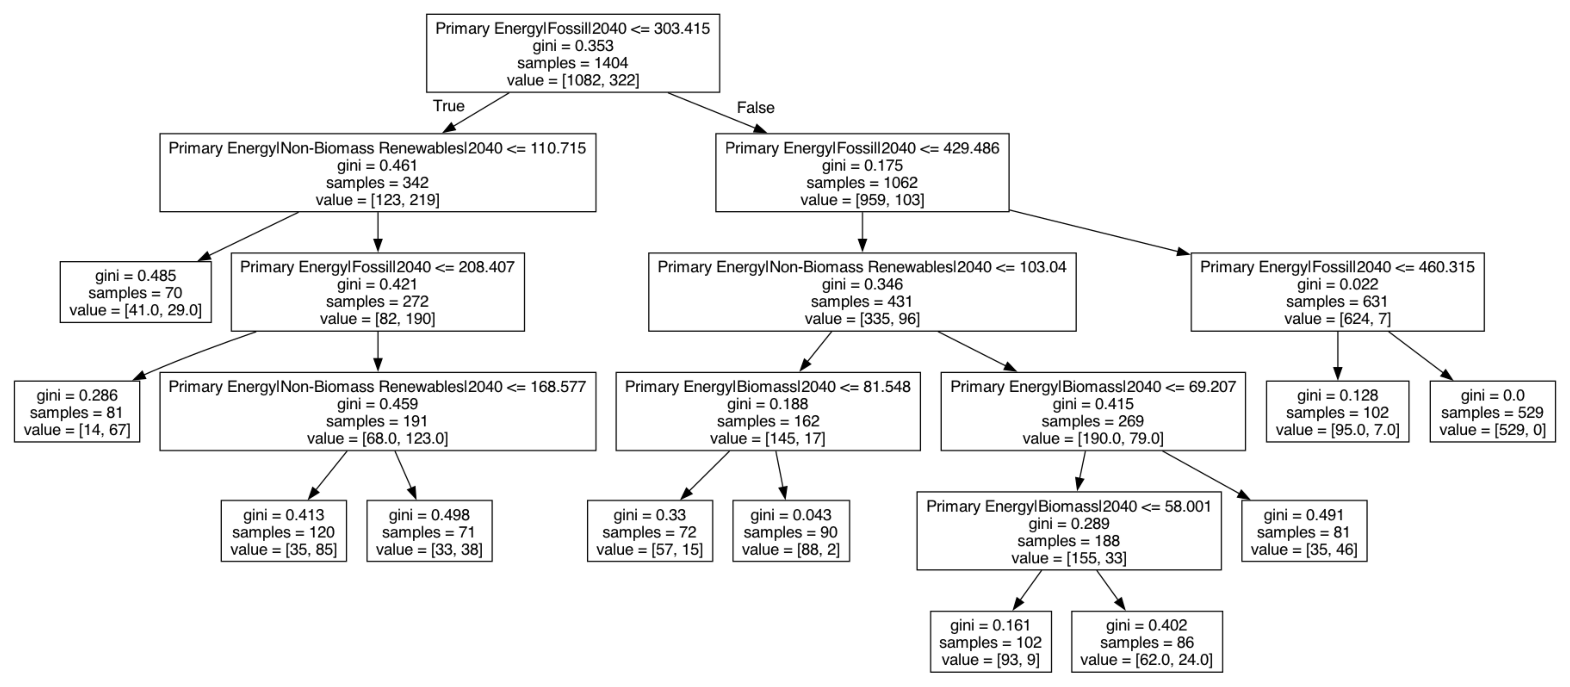

CART feature importances (non-zero):


,importance
Primary Energy|Fossil|2040,0.809358
Primary Energy|Biomass|2040,0.105928
Primary Energy|Non-Biomass Renewables|2040,0.084714


In [67]:
# CART: a readable decision tree
cart_alg = cart.CART(x, y)
cart_alg.build_tree()
fig = cart_alg.show_tree()
fig.set_size_inches((20, 13))
fig.savefig(f"cart_tree_desired_success_{year}.png", dpi=150, bbox_inches="tight")
plt.show()

imp = pd.Series(cart_alg.clf.feature_importances_, index=factors).sort_values(ascending=False)
print("CART feature importances (non-zero):")
display(imp[imp > 0].to_frame("importance"))

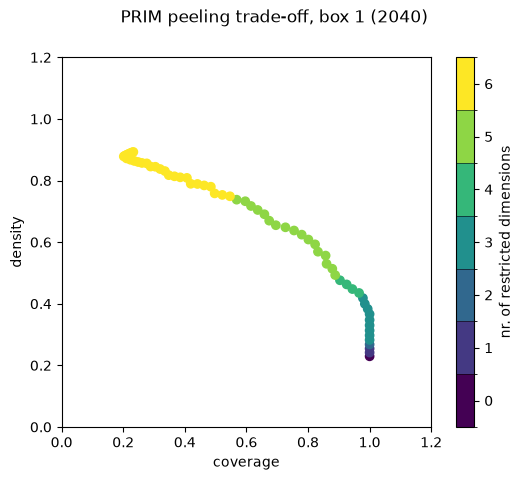

In [68]:
# PRIM: tuned box on the desired region
prim_2030 = prim.Prim(x, y, threshold=0.1)
box1 = prim_2030.find_box()

box1.show_tradeoff()
plt.gcf().suptitle(f"PRIM peeling trade-off, box 1 ({year})")
plt.savefig(f"prim_tradeoff_box1_{year}.png", dpi=150, bbox_inches="tight")
plt.show()

selected box 23 (coverage >= 0.8, max density)
coverage      0.801242
density       0.608491
id           23.000000
k           258.000000
mass          0.301994
mean          0.608491
n           424.000000
res_dim       5.000000
Name: 23, dtype: float64

                                                box 23                        \
                                                   min         max  qp value   
Primary Energy|Fossil|2040                   90.634800  407.748160       NaN   
Final Energy|2040                           247.935624  557.187001       NaN   
Primary Energy|Non-Biomass Renewables|2040  103.055066  299.656686  0.001621   
Primary Energy|Biomass|2040                  52.446190  252.594724  0.020270   
Electrification|2040                          0.281707    0.569654  0.092141   

                                                      
                                            qp value  
Primary Energy|Fossil|2040                  0.006235  
Final Energy|2040

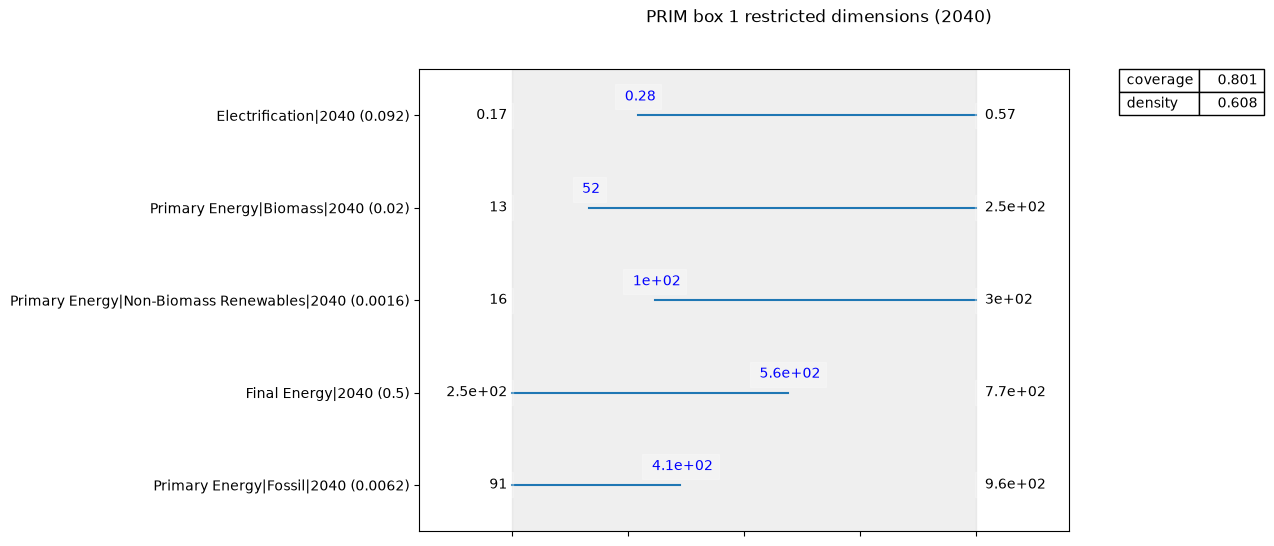

In [69]:
# pick a point on the peeling trade-off: among boxes with coverage >= 0.8, the densest
coverage_floor = 0.8
traj = box1.peeling_trajectory
cand = traj[traj["coverage"] >= coverage_floor]
selected = int(cand.loc[cand["density"].idxmax(), "id"])
print(f"selected box {selected} (coverage >= {coverage_floor}, max density)")

box1.select(selected)
box1.inspect(selected)
box1.inspect(selected, style="graph")
plt.gcf().set_size_inches((10, 6))
plt.gcf().suptitle(f"PRIM box 1 restricted dimensions ({year})")
plt.savefig(f"prim_box1_graph_{year}.png", dpi=150, bbox_inches="tight")
plt.show()

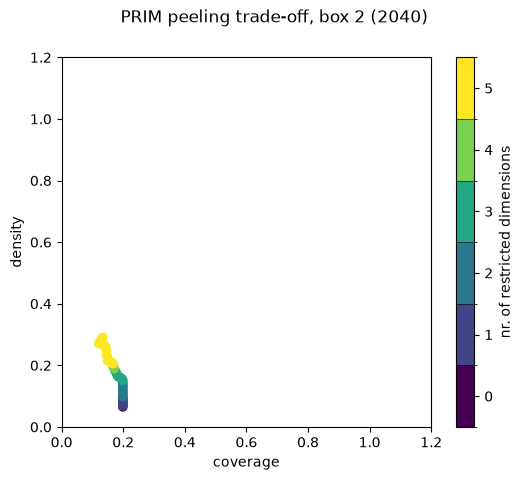


PRIM box statistics (2040):


,coverage,density,mass,res_dim
box 1,0.801242,0.608491,0.301994,5
box 2,0.133540,0.290541,0.105413,5


In [70]:
# equifinality: a second box on the residual
box2 = prim_2030.find_box()
if box2 is None or len(box2.peeling_trajectory) <= 1:
    print("No meaningful second box - box 1 already covers the desired region.")
else:
    box2.show_tradeoff()
    plt.gcf().suptitle(f"PRIM peeling trade-off, box 2 ({year})")
    plt.savefig(f"prim_tradeoff_box2_{year}.png", dpi=150, bbox_inches="tight")
    plt.show()

print(f"\nPRIM box statistics ({year}):")
display(prim_2030.stats_to_dataframe())

## 4. Run at 2050 (mid-century energy/climate mix)

In [71]:
year = 2050
factors = [f"{v}|{year}" for v in BASE_FACTORS]
sub = data[factors + [OUTCOME]].dropna()
x = sub[factors]
y = sub[OUTCOME].values

print(f"===== {year} =====")
print(f"{len(sub)}/{len(data)} scenarios complete on all {len(factors)} factors")
print(f"{y.sum()} desired cases, baseline density = {y.mean():.1%}")

===== 2050 =====
1404/1599 scenarios complete on all 6 factors
322 desired cases, baseline density = 22.9%


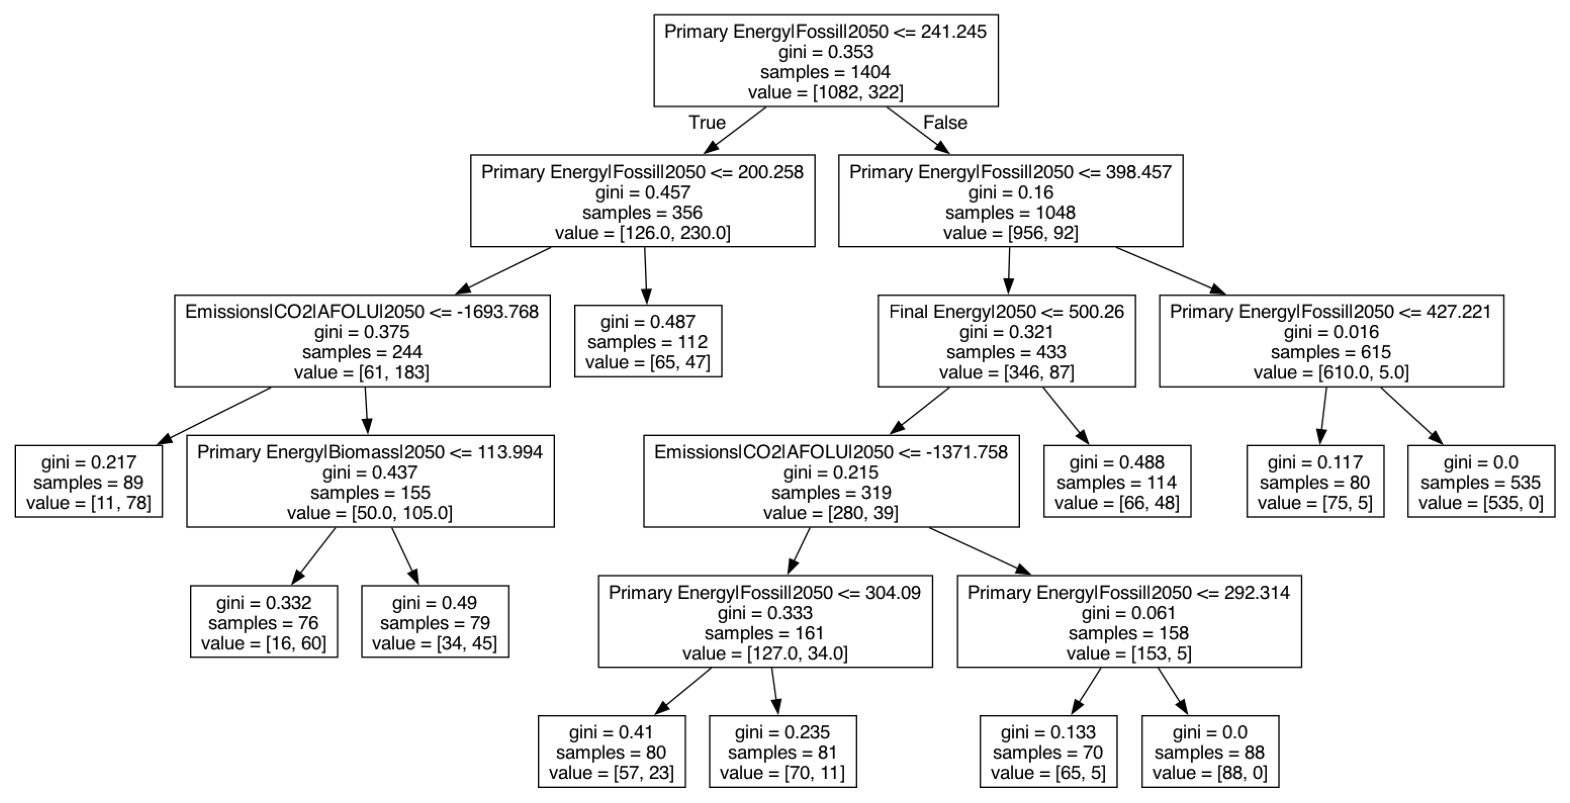

CART feature importances (non-zero):


,importance
Primary Energy|Fossil|2050,0.877997
Final Energy|2050,0.064516
Emissions|CO2|AFOLU|2050,0.041377
Primary Energy|Biomass|2050,0.016110


In [72]:
# CART: a readable decision tree
cart_alg = cart.CART(x, y)
cart_alg.build_tree()
fig = cart_alg.show_tree()
fig.set_size_inches((20, 13))
fig.savefig(f"cart_tree_desired_success_{year}.png", dpi=150, bbox_inches="tight")
plt.show()

imp = pd.Series(cart_alg.clf.feature_importances_, index=factors).sort_values(ascending=False)
print("CART feature importances (non-zero):")
display(imp[imp > 0].to_frame("importance"))

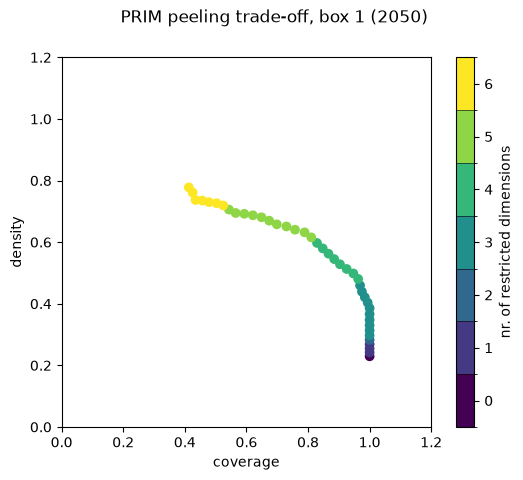

In [73]:
# PRIM: tuned box on the desired region
prim_2050 = prim.Prim(x, y, threshold=0.7)
box1 = prim_2050.find_box()

box1.show_tradeoff()
plt.gcf().suptitle(f"PRIM peeling trade-off, box 1 ({year})")
plt.savefig(f"prim_tradeoff_box1_{year}.png", dpi=150, bbox_inches="tight")
plt.show()

selected box 40 (coverage >= 0.4, max density)
coverage      0.413043
density       0.777778
id           40.000000
k           133.000000
mass          0.121795
mean          0.777778
n           171.000000
res_dim       6.000000
Name: 40, dtype: float64

                                                  box 40              \
                                                     min         max   
Primary Energy|Fossil|2050                     42.077433  355.953580   
Emissions|CO2|AFOLU|2050                   -19376.047191  544.262400   
Final Energy|2050                             242.848576  647.778742   
Primary Energy|Biomass|2050                    78.400336  144.622050   
Primary Energy|Non-Biomass Renewables|2050    191.219653  473.451635   
Electrification|2050                            0.383595    0.739924   

                                                                
                                            qp value  qp value  
Primary Energy|Fossil|2050          

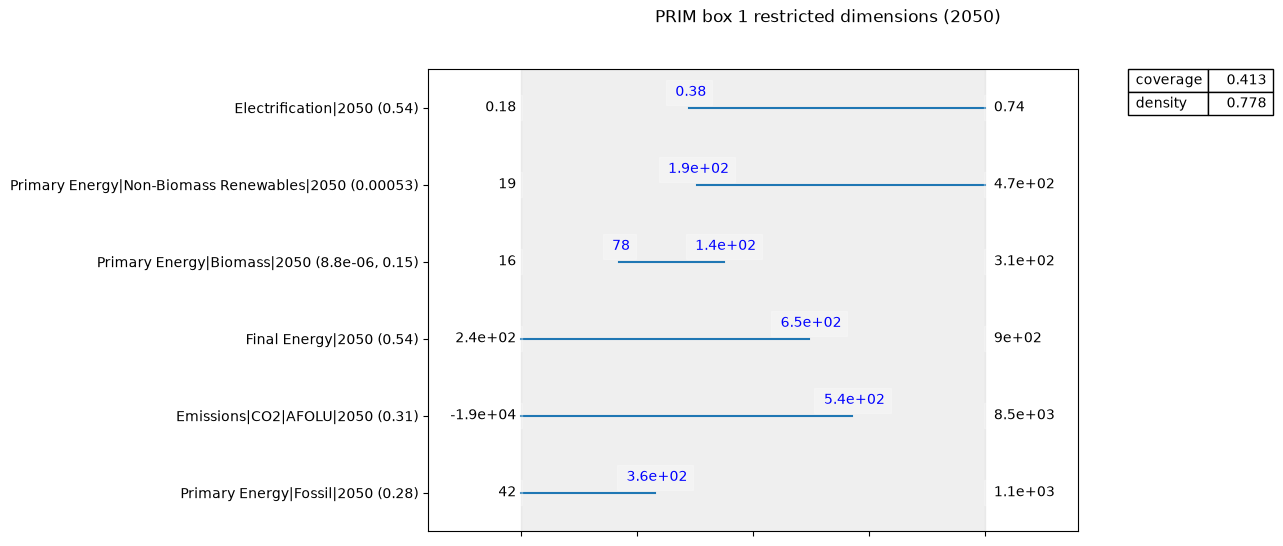

In [74]:
# pick a point on the peeling trade-off: among boxes with coverage >= 0.8, the densest
coverage_floor = 0.4
traj = box1.peeling_trajectory
cand = traj[traj["coverage"] >= coverage_floor]
selected = int(cand.loc[cand["density"].idxmax(), "id"])
print(f"selected box {selected} (coverage >= {coverage_floor}, max density)")

box1.select(selected)
box1.inspect(selected)
box1.inspect(selected, style="graph")
plt.gcf().set_size_inches((10, 6))
plt.gcf().suptitle(f"PRIM box 1 restricted dimensions ({year})")
plt.savefig(f"prim_box1_graph_{year}.png", dpi=150, bbox_inches="tight")
plt.show()

In [75]:
box1.inspect_tradeoff()

alt.VConcatChart(...)

In [76]:
# equifinality: a second box on the residual
box2 = prim_2050.find_box()
if box2 is None or len(box2.peeling_trajectory) <= 1:
    print("No meaningful second box - box 1 already covers the desired region.")
else:
    box2.show_tradeoff()
    plt.gcf().suptitle(f"PRIM peeling trade-off, box 2 ({year})")
    plt.savefig(f"prim_tradeoff_box2_{year}.png", dpi=150, bbox_inches="tight")
    plt.show()

print(f"\nPRIM box statistics ({year}):")
display(prim_2050.stats_to_dataframe())

No meaningful second box - box 1 already covers the desired region.

PRIM box statistics (2050):


,coverage,density,mass,res_dim
box 1,0.413043,0.777778,0.121795,6
box 2,0.586957,0.153285,0.878205,0


selected box 0 (coverage >= 0.15, max density)
coverage       0.586957
density        0.153285
id             0.000000
k            189.000000
mass           0.878205
mean           0.153285
n           1233.000000
res_dim        0.000000
Name: 0, dtype: float64

Empty DataFrame
Columns: [(box 0, min), (box 0, max), (box 0, qp value), (box 0, qp value)]
Index: []



/Users/a.salgas/summer_robust_decision_making/.venv/lib/python3.11/site-packages/ema_workbench/analysis/scenario_discovery_util.py:555: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(top=-0.5, bottom=nr_unc - 0.5)


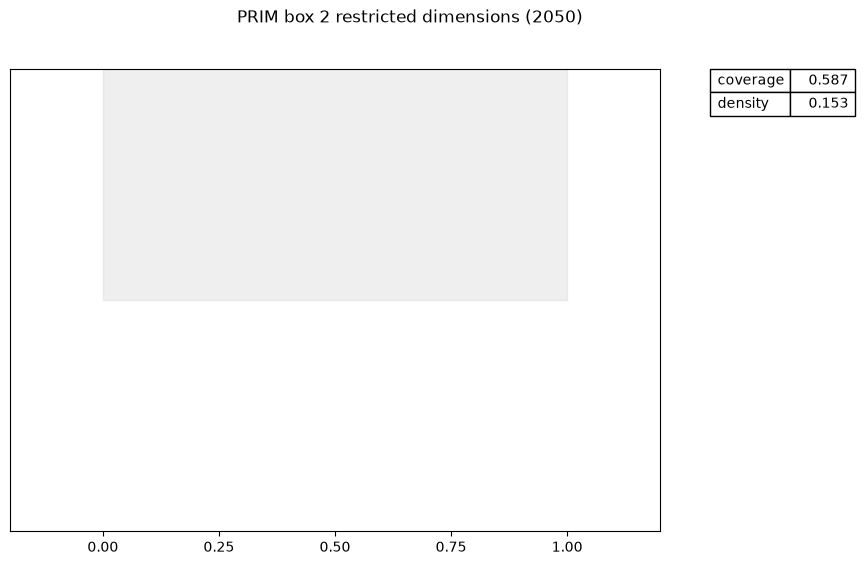

In [77]:
# pick a point on the peeling trade-off: among boxes with coverage >= 0.8, the densest
coverage_floor = 0.15
traj = box2.peeling_trajectory
cand = traj[traj["coverage"] >= coverage_floor]
selected = int(cand.loc[cand["density"].idxmax(), "id"])
print(f"selected box {selected} (coverage >= {coverage_floor}, max density)")

box2.select(selected)
box2.inspect(selected)
box2.inspect(selected, style="graph")
plt.gcf().set_size_inches((10, 6))
plt.gcf().suptitle(f"PRIM box 2 restricted dimensions ({year})")
plt.savefig(f"prim_box2_graph_{year}.png", dpi=150, bbox_inches="tight")
plt.show()

In [78]:
box2.inspect_tradeoff()

alt.VConcatChart(...)

## Caveat

These factors are model **outputs**, not controlled inputs (the ensemble is a heterogeneous
multi-model collection), so the boxes are **descriptive/diagnostic**, not causal. The outcome is a
single threshold choice (NZ <= 2070, cumulative CCS <= 1000 Gt); per the methodology reference it's
worth re-running with neighbouring thresholds before treating the restricted dimensions as a stable
finding. And as flagged in section 1, GSAT temperature and BECCS are partly mechanically linked to
the outcome - the robust, forward-looking part of each box is its energy-mix and near-term-CO2
structure.